# Learning Model Error with MCEM and ADKF

See Chapter 8, Section 8.2: Expectation Maximization; Chapter 8, Section 8.3: Auto-Differentiable Kalman Filters.

## Problem setting

This demo uses the Lorenz-63 system with physical state $v=(x,y,z)^\top$ and unknown physical parameters $\vartheta=(\sigma,\rho)$. The continuous-time dynamics are
$$
\begin{aligned}
\dot x &= \sigma(y-x), \\
\dot y &= x(\rho-z)-y, \\
\dot z &= xy-\beta z,
\end{aligned}
$$
with fixed $\beta=8/3$. The truth used in the default run is
$$
\vartheta^\dagger=(\sigma^\dagger,\rho^\dagger)=(10,28),
\qquad \beta=8/3.
$$
Unlike the deterministic parameter-estimation demo, the state is evolved with model noise after each discrete RK4 step:
$$
v_{j+1}^\dagger=\Psi_{\vartheta^\dagger}(v_j^\dagger)+\xi_j^\dagger,
\qquad
\xi_j^\dagger\sim\mathcal{N}(0,\Sigma^\dagger).
$$
The model-error covariance truth is diagonal and isotropic in the default experiment,
$$
\Sigma^\dagger=(\sigma_v^\dagger)^2 I_3,
\qquad \sigma_v^\dagger=0.04.
$$
The displayed controls let students change the number of observations, the true model-noise standard deviation, and the observation-noise standard deviation before comparing MCEM and ADKF.
The observation operator measures only the first state component,
$$
H v = x,
$$
and the noisy observations satisfy
$$
Y^\dagger=\{y^\dagger_1,\ldots,y^\dagger_J\},
\qquad
y^\dagger_{j+1}=H v^\dagger_{j+1}+\eta^\dagger_{j+1},
\qquad
\eta^\dagger_{j+1}\sim\mathcal{N}(0,\Gamma),
$$
with default $\Gamma=\sigma_y^2 I$ and $\sigma_y=1$. The complete unknown parameter is
$$
\theta=\{\vartheta,\Sigma\}.
$$
The goal is to estimate both the physical parameters and the strength of the model error from a single partial observation trajectory.

## MCEM formulation

Because the latent trajectory is unobserved, the marginal likelihood requires integrating over all possible state paths:
$$
\mathbb{P}(Y^\dagger\mid\theta)
=\int \mathbb{P}(Y^\dagger\mid V^\dagger,\theta)\mathbb{P}(V^\dagger\mid\theta)\,dV^\dagger.
$$
Monte Carlo expectation maximization treats $V^\dagger$ as missing data. The observation part of the complete-data log-likelihood is
$$
\log\mathbb{P}(Y^\dagger\mid V^\dagger,\theta)
=-\frac{1}{2}\sum_{j=0}^{J-1}|y^\dagger_{j+1}-Hv^\dagger_{j+1}|_\Gamma^2+c_1,
$$
and the transition part is
$$
\log\mathbb{P}(V^\dagger\mid\theta)
=-\frac{1}{2}|v_0^\dagger-m_0|_{C_0}^2
-\frac{1}{2}\log\det(\Sigma)
-\frac{1}{2}\sum_{j=0}^{J-1}|v^\dagger_{j+1}-\Psi_\vartheta(v_j^\dagger)|_\Sigma^2+c_2.
$$
With smoothing samples $\{(V^\dagger)^{(n)}\}_{n=1}^N$ from
$q^\ell(V^\dagger)=\mathbb{P}(V^\dagger\mid Y^\dagger,\theta^\ell)$, the empirical M-step objective is
$$
L(\theta;q^\ell)\approx
c-\frac{1}{2}\log\det(\Sigma)
-\frac{1}{2N}\sum_{n=1}^N\sum_{j=0}^{J-1}
\left((v^\dagger_{j+1})^{(n)}-\Psi_\vartheta((v_j^\dagger)^{(n)})\right)^\top
\Sigma^{-1}
\left((v^\dagger_{j+1})^{(n)}-\Psi_\vartheta((v_j^\dagger)^{(n)})\right).
$$
The covariance update has the closed form
$$
\Sigma^{\ell+1}=
\frac{1}{N}\sum_{n=1}^N\sum_{j=0}^{J-1}
\left((v^\dagger_{j+1})^{(n)}-\Psi_\vartheta((v_j^\dagger)^{(n)})\right)
\otimes
\left((v^\dagger_{j+1})^{(n)}-\Psi_\vartheta((v_j^\dagger)^{(n)})\right),
$$
while the physical parameters are updated by ascent,
$$
\vartheta^{\ell+1}
=\vartheta^\ell+\alpha D_\vartheta J\left(\vartheta^\ell,\{(V^\dagger)^{(n)}\}_{n=1}^N\right).
$$

## ADKF formulation

Auto-differentiable Kalman filtering maximizes the sequential marginal likelihood approximation
$$
\log\mathbb{P}(Y^\dagger\mid\theta)
=\sum_{j=0}^{J-1}\log\mathbb{P}(y^\dagger_{j+1}\mid Y^\dagger_j,\theta).
$$
Using the Gaussian predictive approximation
$$
\mathbb{P}(v^\dagger_{j+1}\mid Y^\dagger_j,\theta)\approx
\mathcal{N}(\hat m_{j+1}(\theta),\hat C_{j+1}(\theta)),
$$
the predictive observation moments are
$$
\mathbb{E}[y^\dagger_{j+1}\mid Y^\dagger_j,\theta]=H\hat m_{j+1}(\theta),
$$
$$
S_{j+1}(\theta)=\operatorname{Cov}[y^\dagger_{j+1}\mid Y^\dagger_j,\theta]
=H\hat C_{j+1}(\theta)H^\top+\Gamma.
$$
The objective is
$$
J(\theta)=
-\frac{1}{2}\sum_{j=0}^{J-1}|y^\dagger_{j+1}-H\hat m_{j+1}(\theta)|_{S_{j+1}(\theta)}^2
-\frac{1}{2}\sum_{j=0}^{J-1}\log\det(S_{j+1}(\theta)),
$$
with gradient update
$$
\theta^{\ell+1}=\theta^\ell+\alpha^\ell DJ(\theta^\ell).
$$
We report
$$
E_\sigma=|\hat\sigma-\sigma^\dagger|,
\qquad
E_\rho=|\hat\rho-\rho^\dagger|,
$$
$$
E_\Sigma=\|\hat\Sigma-(\sigma_v^\dagger)^2I\|_F,
$$
and trajectory error
$$
\operatorname{RMSE}=
\sqrt{\frac{1}{J+1}\sum_{j=0}^{J}\|\hat v_j-v_j^\dagger\|_2^2}.
$$


**Parameter exploration.**

- Increase `model_noise_std` to see why deterministic parameter fitting becomes less appropriate and why estimating $\Sigma$ matters.
- Increase `obs_count` to give ADKF and MCEM more sequential evidence; parameter estimates should become more stable.
- Compare `smoother_samples` and `mcem_iterations`: more samples stabilize the covariance update, while more MCEM iterations reveal whether the M-step is moving consistently.
- Toggle `force_retrain` only when you want to ignore an existing checkpoint and recompute the iterative estimates.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `obs_count` | `model_noise_std` | `smoother_samples` | `mcem_iterations` | Purpose |
|---:|---:|---:|---:|---|
| 60 | 0.02 | 30 | 5 | Mild model error; physical parameters dominate the comparison. |
| 80 | 0.04 | 40 | 6 | Balanced default with visible covariance learning. |
| 120 | 0.08 | 60 | 8 | Stronger model error; covariance estimates become central. |


Loaded checkpoint: checkpoints/learning_model_error_mcem_adkf/adkf_mcem/35dd8a517a29.pkl
Parameter estimates
Truth: sigma=10.000, rho=28.000, model-noise std=0.0400
ADKF:  sigma=10.001, rho=27.799, model-noise std=0.1501, RMSE=10.075
MCEM:  sigma=9.907, rho=28.047, model-noise std=0.2192, RMSE=8.946
ADKF absolute errors: [0.00133589 0.20141842]
MCEM absolute errors: [0.09296666 0.04714056]
MCEM covariance Frobenius error: 0.080591


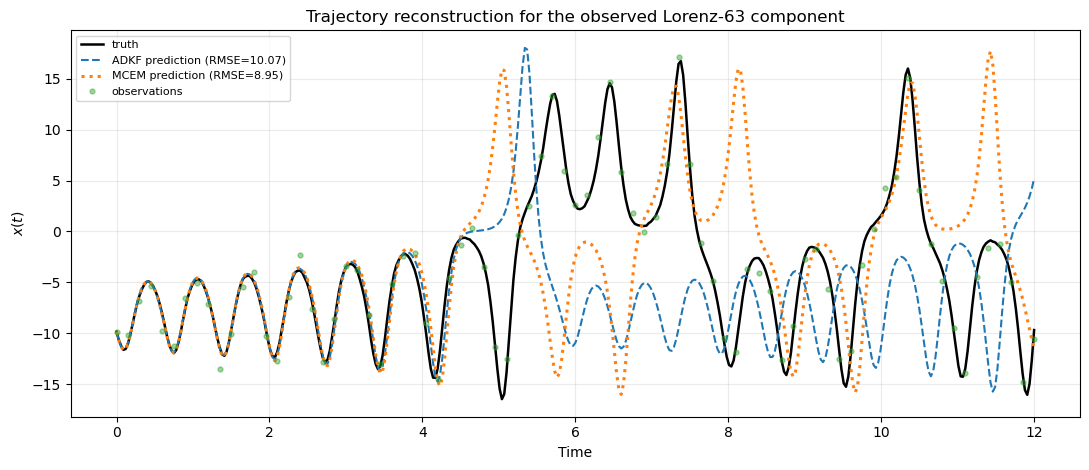

In [1]:
import hashlib
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

DEFAULTS = {
    "true_sigma": 10.0,
    "true_rho": 28.0,
    "beta": 8.0 / 3.0,
    "dt": 0.03,
    "obs_interval_steps": 5,
    "obs_count": 80,
    "model_noise_std": 0.04,
    "observation_noise": 1.0,
    "init_sigma": 12.0,
    "init_rho": 25.0,
    "init_model_noise_std": 0.12,
    "adkf_maxiter": 80,
    "mcem_iterations": 6,
    "smoother_samples": 40,
    "random_seed": 12,
    "force_retrain": False,
}

use_default = False #@param {type:"boolean"}
obs_count = 80 #@param {type:"slider", min:40, max:160, step:10}
model_noise_std = 0.04 #@param {type:"slider", min:0.0, max:0.12, step:0.01}
observation_noise = 1.0 #@param {type:"slider", min:0.5, max:2.0, step:0.25}
adkf_maxiter = 80 #@param {type:"slider", min:20, max:160, step:20}
mcem_iterations = 6 #@param {type:"slider", min:2, max:12, step:1}
smoother_samples = 40 #@param {type:"slider", min:10, max:100, step:10}
force_retrain = False #@param {type:"boolean"}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "obs_count": int(obs_count),
        "model_noise_std": float(model_noise_std),
        "observation_noise": float(observation_noise),
        "adkf_maxiter": int(adkf_maxiter),
        "mcem_iterations": int(mcem_iterations),
        "smoother_samples": int(smoother_samples),
        "force_retrain": bool(force_retrain),
    })


def checkpoint_path(method_name, params):
    cache_params = {k: v for k, v in params.items() if k != "force_retrain"}
    key = hashlib.sha256(json.dumps(cache_params, sort_keys=True).encode()).hexdigest()[:12]
    path = Path("checkpoints") / "learning_model_error_mcem_adkf" / method_name
    path.mkdir(parents=True, exist_ok=True)
    return path / f"{key}.pkl"


def save_checkpoint(path, payload):
    with open(path, "wb") as f:
        pickle.dump(payload, f)


def load_checkpoint(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def rhs(v, sigma, rho, beta):
    x, y, z = v
    return np.array([sigma * (y - x), x * (rho - z) - y, x * y - beta * z], dtype=float)


def rk4(v, sigma, rho, beta, dt):
    k1 = rhs(v, sigma, rho, beta)
    k2 = rhs(v + 0.5 * dt * k1, sigma, rho, beta)
    k3 = rhs(v + 0.5 * dt * k2, sigma, rho, beta)
    k4 = rhs(v + dt * k3, sigma, rho, beta)
    return v + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0


def flow(v, theta, params):
    return rk4(v, theta[0], theta[1], params["beta"], params["dt"])


def jacobian_flow(v, theta, params, eps=1e-4):
    base = flow(v, theta, params)
    J = np.zeros((3, 3))
    for i in range(3):
        e = np.zeros(3)
        e[i] = eps
        J[:, i] = (flow(v + e, theta, params) - flow(v - e, theta, params)) / (2 * eps)
    return J


def simulate_data(params):
    rng = np.random.default_rng(params["random_seed"])
    x0 = np.array([1.0, 1.0, 1.0])
    for _ in range(300):
        x0 = flow(x0, (params["true_sigma"], params["true_rho"]), params)
    total_steps = params["obs_count"] * params["obs_interval_steps"]
    states = np.empty((total_steps + 1, 3))
    obs = np.full((total_steps + 1, 1), np.nan)
    states[0] = x0
    obs[0, 0] = states[0, 0] + params["observation_noise"] * rng.normal()
    for k in range(total_steps):
        states[k + 1] = flow(states[k], (params["true_sigma"], params["true_rho"]), params)
        states[k + 1] += params["model_noise_std"] * rng.normal(size=3)
        if (k + 1) % params["obs_interval_steps"] == 0:
            obs[k + 1, 0] = states[k + 1, 0] + params["observation_noise"] * rng.normal()
    return states, obs


def ekf_filter(theta, sigma_v, obs, params, return_predictions=False):
    q = max(float(sigma_v) ** 2, 1e-8)
    r = params["observation_noise"] ** 2
    H = np.array([[1.0, 0.0, 0.0]])
    m = np.array([1.0, 1.0, 1.0])
    for _ in range(300):
        m = flow(m, theta, params)
    C = np.eye(3) * 2.0
    means, covs, pred_means, pred_covs, gains = [], [], [], [], []
    nll = 0.0
    for k in range(1, len(obs)):
        F = jacobian_flow(m, theta, params)
        m_pred = flow(m, theta, params)
        C_pred = F @ C @ F.T + q * np.eye(3)
        pred_means.append(m_pred.copy())
        pred_covs.append(C_pred.copy())
        if np.isfinite(obs[k, 0]):
            S = H @ C_pred @ H.T + r
            innovation = obs[k] - H @ m_pred
            nll += 0.5 * (np.log(S[0, 0]) + innovation[0] ** 2 / S[0, 0])
            K = C_pred @ H.T / S[0, 0]
            m = m_pred + (K @ innovation).ravel()
            I_KH = np.eye(3) - K @ H
            C = I_KH @ C_pred @ I_KH.T + K * r @ K.T
            gains.append(K)
        else:
            m, C = m_pred, C_pred
            gains.append(np.zeros((3, 1)))
        C = 0.5 * (C + C.T) + 1e-8 * np.eye(3)
        means.append(m.copy())
        covs.append(C.copy())
    out = (np.array(means), np.array(covs), float(nll))
    if return_predictions:
        return out + (np.array(pred_means), np.array(pred_covs))
    return out


def adkf_objective(raw, obs, params):
    sigma = np.exp(raw[0])
    rho = 1.0 + np.exp(raw[1])
    sigma_v = np.exp(raw[2])
    if not (2 < sigma < 30 and 5 < rho < 60 and 1e-4 < sigma_v < 1):
        return 1e8
    try:
        _, _, nll = ekf_filter((sigma, rho), sigma_v, obs, params)
        penalty = 1e-3 * ((sigma - 10) ** 2 + (rho - 28) ** 2)
        return nll + penalty
    except Exception:
        return 1e8


def run_adkf(obs, params):
    raw0 = np.log([params["init_sigma"], params["init_rho"] - 1.0, params["init_model_noise_std"]])
    opt = minimize(
        lambda raw: adkf_objective(raw, obs, params),
        raw0,
        method="Nelder-Mead",
        options={"maxiter": params["adkf_maxiter"], "xatol": 1e-3, "fatol": 1e-3},
    )
    raw = opt.x
    return {
        "theta": np.array([np.exp(raw[0]), 1.0 + np.exp(raw[1])]),
        "sigma_v": float(np.exp(raw[2])),
        "loss": float(opt.fun),
        "success": bool(opt.success),
    }


def rts_smoother(theta, sigma_v, obs, params):
    means, covs, _, pred_means, pred_covs = ekf_filter(theta, sigma_v, obs, params, True)
    m_s = means.copy()
    C_s = covs.copy()
    for t in range(len(means) - 2, -1, -1):
        F = jacobian_flow(means[t], theta, params)
        C_pred_next = pred_covs[t + 1]
        G = covs[t] @ F.T @ np.linalg.pinv(C_pred_next)
        m_s[t] = means[t] + G @ (m_s[t + 1] - pred_means[t + 1])
        C_s[t] = covs[t] + G @ (C_s[t + 1] - C_pred_next) @ G.T
        C_s[t] = 0.5 * (C_s[t] + C_s[t].T) + 1e-8 * np.eye(3)
    return m_s, C_s


def sample_smoother_paths(theta, sigma_v, obs, params):
    rng = np.random.default_rng(params["random_seed"] + 21)
    means, covs = rts_smoother(theta, sigma_v, obs, params)
    samples = []
    for _ in range(params["smoother_samples"]):
        path = []
        for t in range(len(means)):
            vals, vecs = np.linalg.eigh(0.5 * (covs[t] + covs[t].T))
            vals = np.clip(vals, 1e-6, 0.25)
            cov = vecs @ np.diag(vals) @ vecs.T
            path.append(rng.multivariate_normal(means[t], 0.2 * cov + 1e-8 * np.eye(3)))
        path = np.array(path)
        samples.append(path)
    initial = np.repeat(means[0][None, None, :], params["smoother_samples"], axis=0)
    return np.concatenate([initial, np.array(samples)], axis=1)


def m_step_objective(theta, samples, sigma_diag, params, center):
    sigma, rho = theta
    if not (2 < sigma < 30 and 5 < rho < 60):
        return 1e8
    inv_diag = 1.0 / np.maximum(sigma_diag, 1e-8)
    loss = 0.0
    for path in samples:
        pred = np.array([flow(path[k], theta, params) for k in range(len(path) - 1)])
        residual = path[1:] - pred
        loss += np.mean(np.sum(residual**2 * inv_diag, axis=1))
    weak_prior = 0.02 * np.sum((np.array([sigma, rho]) - center) ** 2)
    return loss / len(samples) + weak_prior


def run_mcem(obs, start, params):
    theta = start["theta"].copy()
    sigma_v = min(start["sigma_v"], 0.08)
    history = []
    for _ in range(params["mcem_iterations"]):
        samples = sample_smoother_paths(theta, sigma_v, obs, params)
        residuals = []
        for path in samples:
            pred = np.array([flow(path[k], theta, params) for k in range(len(path) - 1)])
            residuals.append(path[1:] - pred)
        residuals = np.concatenate(residuals, axis=0)
        sigma_diag = np.clip(np.mean(residuals**2, axis=0), 1e-7, 0.05)
        opt = minimize(
            lambda th: m_step_objective(th, samples, sigma_diag, params, theta),
            theta,
            method="L-BFGS-B",
            bounds=[(2, 30), (5, 60)],
            options={"maxiter": 40},
        )
        theta = opt.x
        sigma_v = float(np.sqrt(np.mean(sigma_diag)))
        history.append((theta.copy(), sigma_v, sigma_diag.copy()))
    return {"theta": theta, "sigma_v": sigma_v, "sigma_diag": history[-1][2], "history": history}


def trajectory_rmse(theta, states, params):
    pred = np.empty_like(states)
    pred[0] = states[0]
    for k in range(len(states) - 1):
        pred[k + 1] = flow(pred[k], theta, params)
    return float(np.sqrt(np.mean((pred - states) ** 2))), pred


states, obs = simulate_data(params)
ckpt = checkpoint_path("adkf_mcem", params)
if ckpt.exists() and not params["force_retrain"]:
    payload = load_checkpoint(ckpt)
    print(f"Loaded checkpoint: {ckpt}")
else:
    adkf = run_adkf(obs, params)
    mcem = run_mcem(obs, adkf, params)
    payload = {"adkf": adkf, "mcem": mcem}
    save_checkpoint(ckpt, payload)
    print(f"Saved checkpoint: {ckpt}")

adkf = payload["adkf"]
mcem = payload["mcem"]
rmse_adkf, pred_adkf = trajectory_rmse(adkf["theta"], states, params)
rmse_mcem, pred_mcem = trajectory_rmse(mcem["theta"], states, params)
true_theta = np.array([params["true_sigma"], params["true_rho"]])
true_sigma_diag = (params["model_noise_std"] ** 2) * np.ones(3)

print("Parameter estimates")
print(f"Truth: sigma={true_theta[0]:.3f}, rho={true_theta[1]:.3f}, model-noise std={params['model_noise_std']:.4f}")
print(f"ADKF:  sigma={adkf['theta'][0]:.3f}, rho={adkf['theta'][1]:.3f}, model-noise std={adkf['sigma_v']:.4f}, RMSE={rmse_adkf:.3f}")
print(f"MCEM:  sigma={mcem['theta'][0]:.3f}, rho={mcem['theta'][1]:.3f}, model-noise std={mcem['sigma_v']:.4f}, RMSE={rmse_mcem:.3f}")
print(f"ADKF absolute errors: {np.abs(adkf['theta'] - true_theta)}")
print(f"MCEM absolute errors: {np.abs(mcem['theta'] - true_theta)}")
print(f"MCEM covariance Frobenius error: {np.linalg.norm(np.diag(mcem['sigma_diag']) - np.diag(true_sigma_diag)):.6f}")

t = np.arange(len(states)) * params["dt"]
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(t, states[:, 0], "k-", lw=1.8, label="truth")
ax.plot(t, pred_adkf[:, 0], "C0--", lw=1.5, label=f"ADKF prediction (RMSE={rmse_adkf:.2f})")
ax.plot(t, pred_mcem[:, 0], "C1:", lw=2.2, label=f"MCEM prediction (RMSE={rmse_mcem:.2f})")
obs_t = np.where(np.isfinite(obs[:, 0]))[0] * params["dt"]
ax.plot(obs_t, obs[np.isfinite(obs[:, 0]), 0], "o", ms=3.5, color="tab:green", alpha=0.45, label="observations")
ax.set_title("Trajectory reconstruction for the observed Lorenz-63 component")
ax.set_xlabel("Time")
ax.set_ylabel("$x(t)$")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
